In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("../data/customer_metrics.csv")

# preview
df.head()


,customer_id,recency_days,total_orders,total_spent
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   4339 non-null   float64
 1   recency_days  4339 non-null   int64  
 2   total_orders  4339 non-null   int64  
 3   total_spent   4339 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB


,customer_id,recency_days,total_orders,total_spent
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.518322,4.271952,2053.797166
std,1721.889758,100.009747,7.705493,8988.247836
min,12346.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,307.245000
50%,15299.000000,51.000000,2.000000,674.450000
75%,16778.500000,142.000000,5.000000,1661.640000
max,18287.000000,374.000000,210.000000,280206.020000


In [3]:
# define churn (90 days inactivity)
df['churn'] = df['recency_days'] > 90

# convert to int (0/1)
df['churn'] = df['churn'].astype(int)

df.head()

,customer_id,recency_days,total_orders,total_spent,churn
0,12346.0,326,1,77183.60,1
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [4]:
df['churn'].value_counts()

churn
0    2890
1    1449
Name: count, dtype: int64

In [5]:
churn_rate = df['churn'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 33.39%


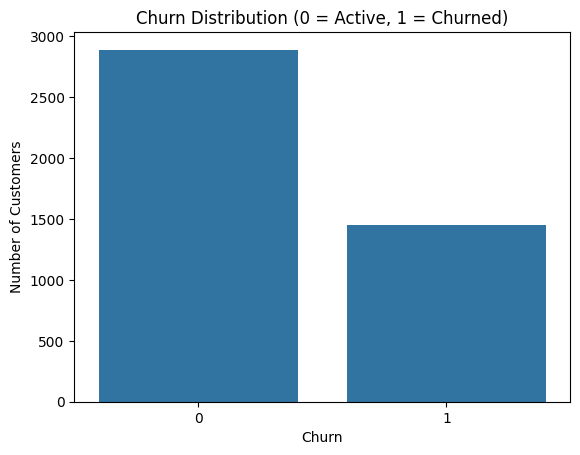

In [6]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution (0 = Active, 1 = Churned)")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
### Insight 1: Overall Churn Rate

Approximately 33.39% of customers have churned based on the 90-day inactivity rule.

This indicates that a significant portion of users do not continue ordering after initial engagement, highlighting a potential retention issue in the platform.

This level of churn suggests the need for early user engagement strategies, especially targeting first-time users.

In [ ]:
## User Activity Analysis
Understanding how frequently customers place orders on the platform.

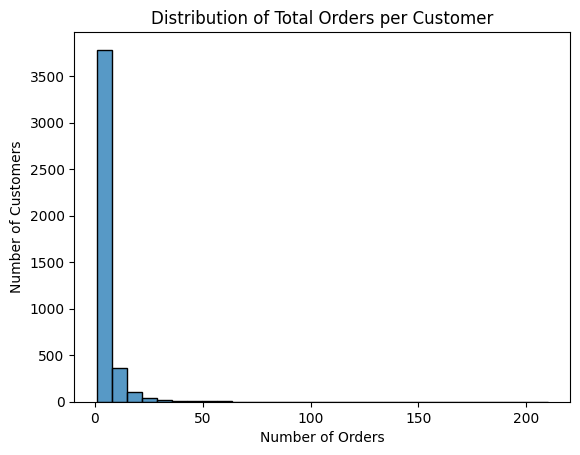

In [7]:
plt.figure()
sns.histplot(df['total_orders'], bins=30)
plt.title("Distribution of Total Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

In [8]:
def segment_orders(x):
    if x == 1:
        return "One-time users"
    elif x <= 3:
        return "Low frequency"
    elif x <= 7:
        return "Medium frequency"
    else:
        return "High frequency"

df['order_segment'] = df['total_orders'].apply(segment_orders)

In [9]:
df['order_segment'].value_counts()

order_segment
One-time users      1494
Low frequency       1343
Medium frequency     945
High frequency       557
Name: count, dtype: int64

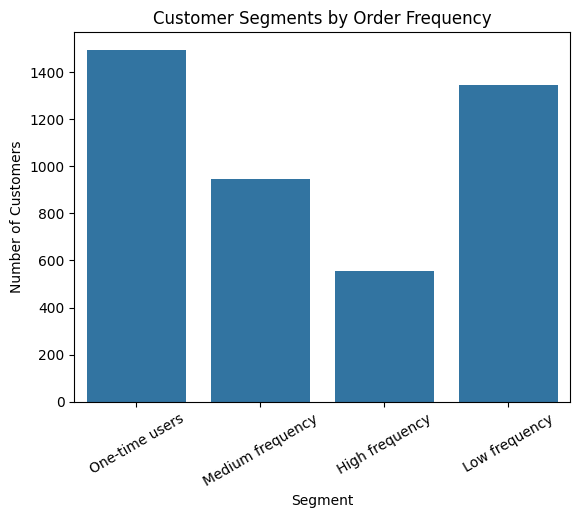

In [10]:
sns.countplot(x='order_segment', data=df)
plt.title("Customer Segments by Order Frequency")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

In [ ]:
### Insight 2: User Activity Distribution

The majority of users fall into the low-frequency segments, with a large proportion placing only one or a few orders.

This indicates that most users do not transition into regular customers, which is a key driver of overall churn.

Only a small percentage of users show high engagement, contributing disproportionately to platform activity.

In [ ]:
## Customer Value Analysis
Identifying high-value customers based on total spending.

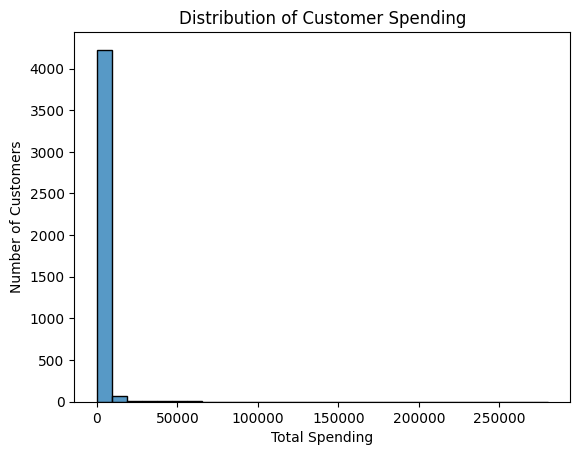

In [11]:
plt.figure()
sns.histplot(df['total_spent'], bins=30)
plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

In [12]:
def segment_spending(x):
    if x < 500:
        return "Low Value"
    elif x < 1500:
        return "Mid Value"
    else:
        return "High Value"

df['value_segment'] = df['total_spent'].apply(segment_spending)

In [13]:
df['value_segment'].value_counts()

value_segment
Low Value     1762
Mid Value     1383
High Value    1194
Name: count, dtype: int64

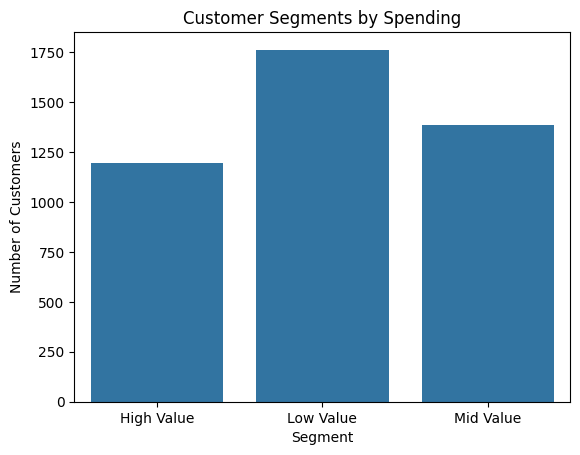

In [14]:
sns.countplot(x='value_segment', data=df)
plt.title("Customer Segments by Spending")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
top_customers = df.sort_values(by='total_spent', ascending=False).head(10)
top_customers[['customer_id', 'total_spent']]

,customer_id,total_spent
1690,14646.0,280206.02
4202,18102.0,259657.30
3729,17450.0,194550.79
3009,16446.0,168472.50
1880,14911.0,143825.06
55,12415.0,124914.53
1334,14156.0,117379.63
3772,17511.0,91062.38
2703,16029.0,81024.84
0,12346.0,77183.60


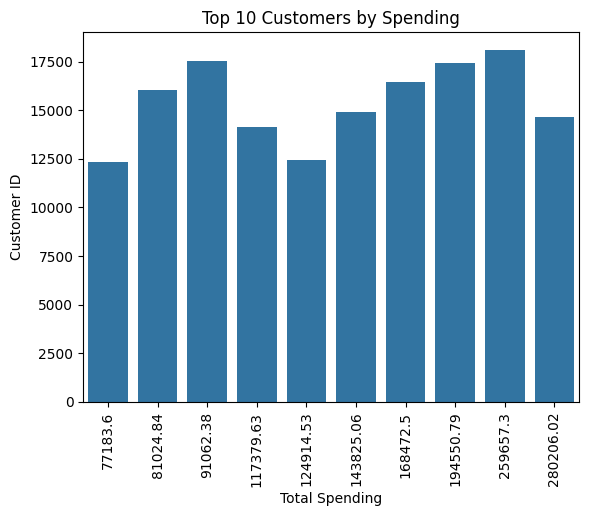

In [18]:
plt.figure()
sns.barplot(x='total_spent', y='customer_id', data=top_customers)
plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spending")
plt.xticks(rotation=90)
plt.ylabel("Customer ID")
plt.show()

In [ ]:
### Insight 3: Customer Value Distribution

Customer spending is highly skewed, with a small group of high-value users accounting for a significant share of total revenue.

Most users fall into the low-value segment, indicating that most customers generate limited revenue.

This highlights the importance of retaining high-value users, as they are critical to the platform’s overall profitability.

In [ ]:
## Churn vs Customer Value
Analyzing whether high-value customers are less likely to churn.

In [19]:
churn_by_value = df.groupby('value_segment')['churn'].mean() * 100
churn_by_value

value_segment
High Value    10.217755
Low Value     52.667423
Mid Value     28.850325
Name: churn, dtype: float64

In [20]:
churn_by_value = churn_by_value.reset_index()
churn_by_value.columns = ['value_segment', 'churn_rate']
churn_by_value

,value_segment,churn_rate
0,High Value,10.217755
1,Low Value,52.667423
2,Mid Value,28.850325


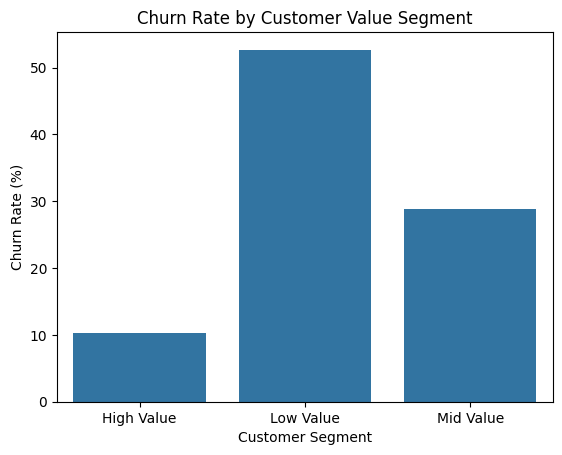

In [21]:
plt.figure()
sns.barplot(x='value_segment', y='churn_rate', data=churn_by_value)
plt.title("Churn Rate by Customer Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

In [ ]:
### Insight 4: Churn vs Customer Value

Churn rates are significantly higher among low-value customers compared to high-value customers.

High-value users show stronger retention, indicating that customers who invest more in the platform are more likely to continue using it.

This suggests that increasing early customer engagement and spending could improve long-term retention.

In [ ]:
## Churn vs User Engagement
Analyzing how order frequency impacts customer churn.

In [22]:
churn_by_orders = df.groupby('order_segment')['churn'].mean() * 100
churn_by_orders

order_segment
High frequency       3.231598
Low frequency       34.177215
Medium frequency    13.227513
One-time users      56.693440
Name: churn, dtype: float64

In [24]:
churn_by_orders = churn_by_orders.reset_index()
churn_by_orders.columns = ['order_segment', 'churn_rate']
churn_by_orders

,order_segment,churn_rate
0,High frequency,3.231598
1,Low frequency,34.177215
2,Medium frequency,13.227513
3,One-time users,56.693440


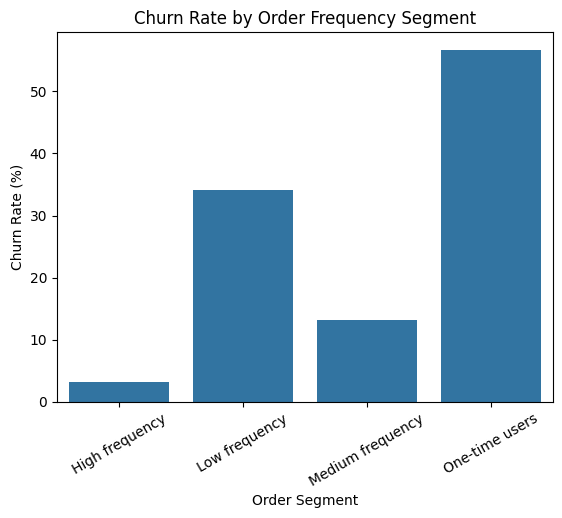

In [25]:
plt.figure()
sns.barplot(x='order_segment', y='churn_rate', data=churn_by_orders)
plt.title("Churn Rate by Order Frequency Segment")
plt.xlabel("Order Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [ ]:
### Insight 5: Churn vs User Engagement

Customers with low order frequency, especially one-time users, show the highest churn rates.

As the number of orders increases, churn significantly decreases, indicating that repeat engagement is a strong predictor of customer retention.

This highlights the importance of converting first-time users into repeat customers as early as possible.

In [26]:
at_risk = df[(df['total_orders'] <= 2) & (df['recency_days'] > 60)]
at_risk[['customer_id', 'total_orders', 'recency_days']].head()

,customer_id,total_orders,recency_days
0,12346.0,1,326
4,12350.0,1,310
6,12353.0,1,204
7,12354.0,1,232
8,12355.0,1,214


In [ ]:
### Insight 6: At-Risk Customers

Customers with low order frequency and high recency are most likely to churn.

These users represent a critical segment where timely interventions such as discounts or reminders can significantly improve retention.

In [ ]:
## Customer Segmentation (RFM Analysis)
Segmenting customers based on Recency, Frequency, and Monetary value.

In [28]:
# Recency (reverse scoring: lower is better)
df['R_score'] = pd.qcut(df['recency_days'], q=4, labels=[4,3,2,1], duplicates='drop')

# Frequency
df['F_score'] = pd.qcut(df['total_orders'].rank(method='first'), q=4, labels=[1,2,3,4])

# Monetary
df['M_score'] = pd.qcut(df['total_spent'].rank(method='first'), q=4, labels=[1,2,3,4])

In [29]:
df[['recency_days','total_orders','total_spent','R_score','F_score','M_score']].head()

,recency_days,total_orders,total_spent,R_score,F_score,M_score
0,326,1,77183.60,1,1,4
1,2,7,4310.00,4,4,4
2,75,4,1797.24,2,3,4
3,19,1,1757.55,3,1,4
4,310,1,334.40,1,1,2


In [30]:
df['RFM_score'] = df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str)

In [31]:
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] >= 3:
        return "Loyal Customers"
    elif row['R_score'] >= 3 and row['F_score'] <= 2:
        return "Potential Loyalists"
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return "At Risk"
    else:
        return "Churned/Low Value"

df['customer_segment'] = df.apply(segment_customer, axis=1)

In [32]:
df['customer_segment'].value_counts()

customer_segment
Churned/Low Value      2136
Loyal Customers         891
Potential Loyalists     666
At Risk                 646
Name: count, dtype: int64

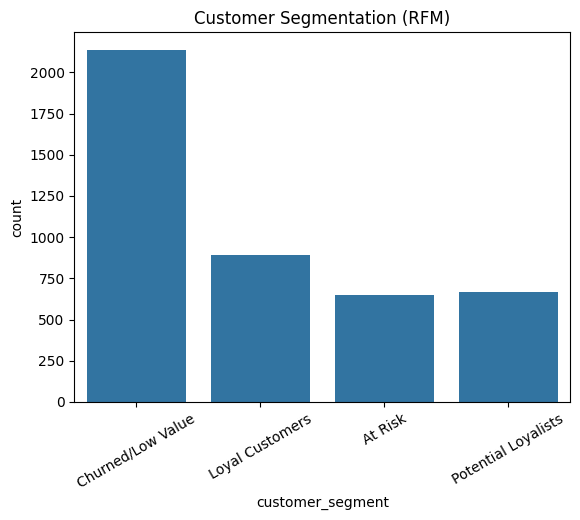

In [33]:
plt.figure()
sns.countplot(x='customer_segment', data=df)
plt.title("Customer Segmentation (RFM)")
plt.xticks(rotation=30)
plt.show()

In [34]:
segment_churn = df.groupby('customer_segment')['churn'].mean() * 100
segment_churn = segment_churn.reset_index()
segment_churn.columns = ['segment', 'churn_rate']
segment_churn

,segment,churn_rate
0,At Risk,54.334365
1,Churned/Low Value,51.404494
2,Loyal Customers,0.000000
3,Potential Loyalists,0.000000


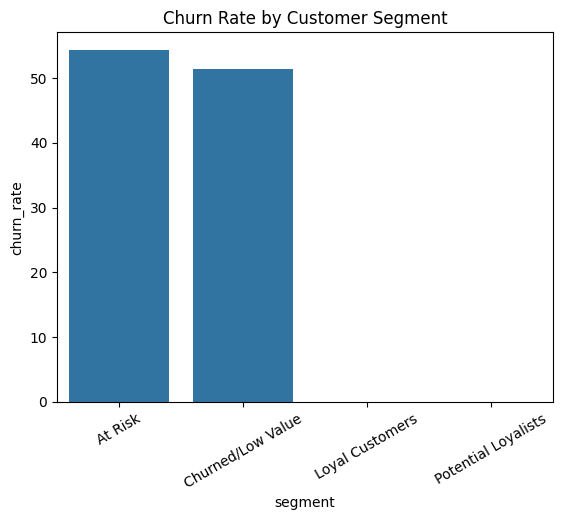

In [35]:
plt.figure()
sns.barplot(x='segment', y='churn_rate', data=segment_churn)
plt.title("Churn Rate by Customer Segment")
plt.xticks(rotation=30)
plt.show()

In [ ]:
### Insight 7: Customer Segmentation and Churn

Customer segmentation reveals clear differences in behavior and churn risk across user groups.

Loyal customers exhibit the lowest churn rates, indicating strong engagement and consistent ordering behavior.

In contrast, low-value and at-risk segments show significantly higher churn rates, highlighting the need for targeted retention strategies.

This segmentation enables the business to prioritize high-value users while designing interventions for at-risk customers.